# Home task: Logistic Regression 

The aim of this work is to build and compare three machine learning models for tumor type determination based on medical features. For this purpose, the breast_cancer dataset from the scikit-learn library was used.

## Import libraries


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn tools
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# fix random for same results
np.random.seed(42)

# nicer plots
sns.set_style("whitegrid")

## Load dataset


In [27]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print("X shape:", X.shape)
print("y shape:", y.shape)

print(y.value_counts())

X shape: (569, 30)
y shape: (569,)
1    357
0    212
dtype: int64


## Train-test split

In [28]:
# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (455, 30)
Test: (114, 30)


## Create models


In [29]:
# define models
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),  # scale features
        ("model", LogisticRegression(max_iter=5000, random_state=42))
    ]),
    
    "Linear SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="linear", probability=True, random_state=42))
    ]),
    
    "RBF SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", probability=True, random_state=42))
    ])
}

## Evaluation function


In [30]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    # train model
    model.fit(X_train, y_train)
    
    # predictions
    y_pred = model.predict(X_test)

    # calculate metrics
    result = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred)
    }
    
    return y_pred, result

## Train and compare models


In [31]:
results = []
predictions = {}

# loop over models
for name, model in models.items():
    y_pred, metrics = evaluate_model(model, X_train, X_test, y_train, y_test)
    
    predictions[name] = y_pred
    
    row = {"model": name}
    row.update(metrics)
    results.append(row)

# create dataframe
results_df = pd.DataFrame(results)

# sort by f1 score
results_df = results_df.sort_values(by="f1", ascending=False)

results_df

,model,accuracy,precision,recall,f1
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111
2,RBF SVM,0.982456,0.986111,0.986111,0.986111
1,Linear SVM,0.973684,0.985915,0.972222,0.979021


## Plot results

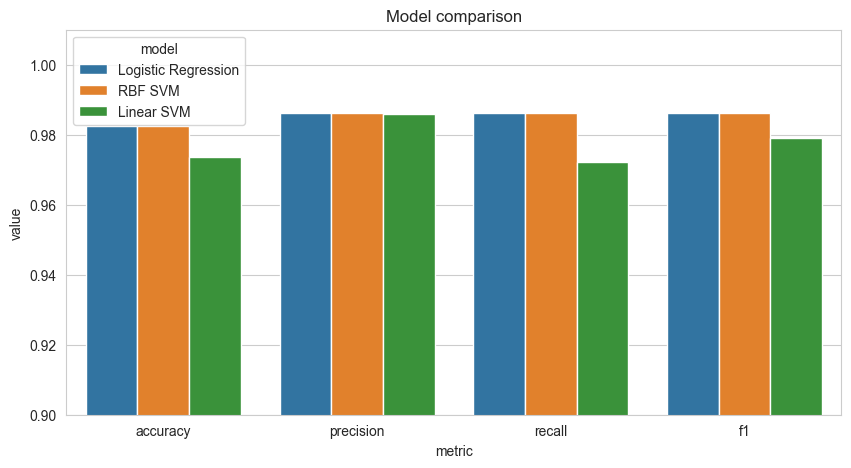

In [32]:
# reshape data for plot
plot_data = results_df.melt(id_vars="model", var_name="metric", value_name="value")

# plot
plt.figure(figsize=(10, 5))
sns.barplot(data=plot_data, x="metric", y="value", hue="model")

plt.title("Model comparison")
plt.ylim(0.9, 1.01)

plt.show()

## Confusion matrices

Check how models make mistakes

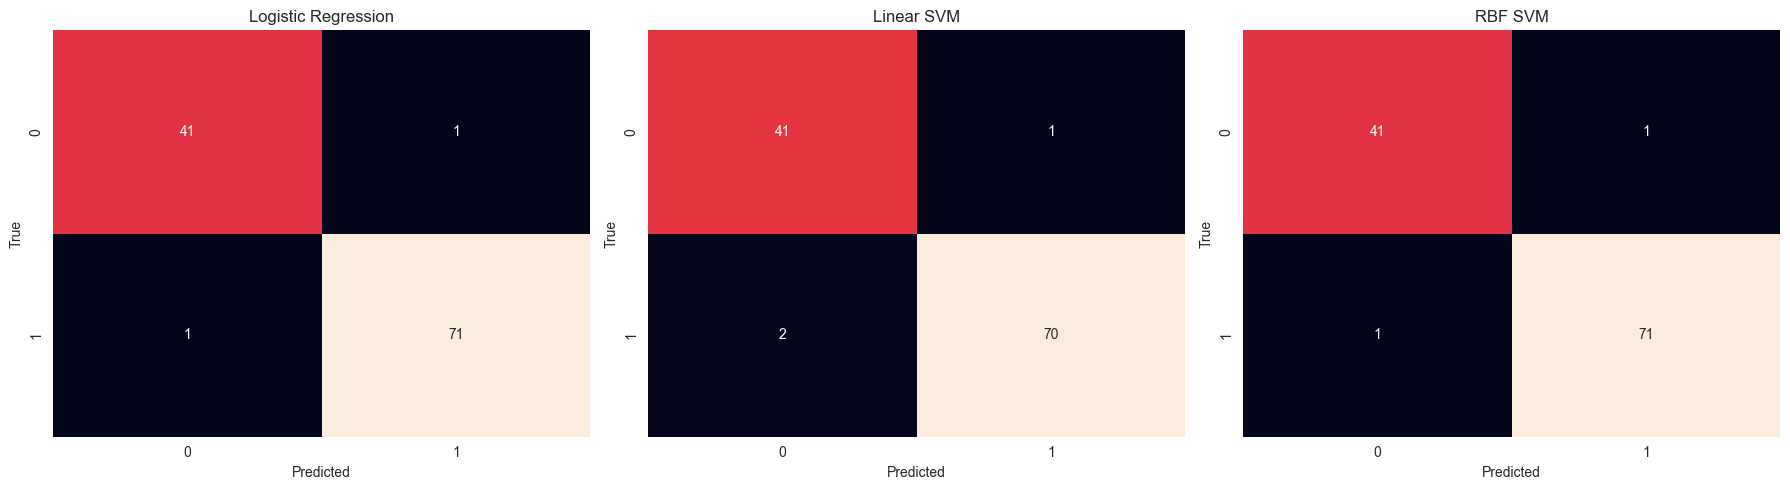

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt="d", cbar=False, ax=ax)
    
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.show()

## Classification report

More detailed metrics

In [34]:
for name, y_pred in predictions.items():
    print("\n", name)
    print(classification_report(y_test, y_pred))


 Logistic Regression
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


 Linear SVM
              precision    recall  f1-score   support

           0       0.95      0.98      0.96        42
           1       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


 RBF SVM
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      

## Conclusion
All models show good results, but SVM with RBF kernel performs slightly better